In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)


E:\file_main\Major_2


In [5]:
import pandas as pd
from src.feature_extractor import extract_features

DATA_PATH = r"E:\file_main\Major_2\data\processed\phishing_urls_final.csv"
df = pd.read_csv(DATA_PATH)

print(df.head())

                                                 url  label
0  https://wiercommercialconstruction.myportfolio...      1
1                            https://l.ead.me/bfjdph      1
2               https://www.urbanluminariadesign.cfd      0
3                            https://l.ead.me/bfwf4a      1
4                          https://www.clickbond.com      0


In [13]:
X = df["url"].apply(extract_features)
X = pd.DataFrame(list(X))
y = df["label"]

In [15]:
print(X.head())
X.shape

   url_length  num_digits  num_special_chars  num_dots  num_hyphens  has_at  \
0          51           0                  6         2            0       0   
1          23           0                  6         2            0       0   
2          36           0                  5         2            0       0   
3          23           1                  6         2            0       0   
4          25           0                  5         2            0       0   

   has_https   entropy  domain_length  path_length  query_length  \
0          1  4.032707             42            1             0   
1          1  3.795089              8            7             0   
2          1  4.252715             28            0             0   
3          1  3.882045              8            7             0   
4          1  3.943465             17            0             0   

   subdomain_depth  num_params  has_fragment  ip_in_url  
0                1           0             0          0  


(91652, 15)

In [16]:
X.describe()
X.isnull().sum()

url_length           0
num_digits           0
num_special_chars    0
num_dots             0
num_hyphens          0
has_at               0
has_https            0
entropy              0
domain_length        0
path_length          0
query_length         0
subdomain_depth      0
num_params           0
has_fragment         0
ip_in_url            0
dtype: int64

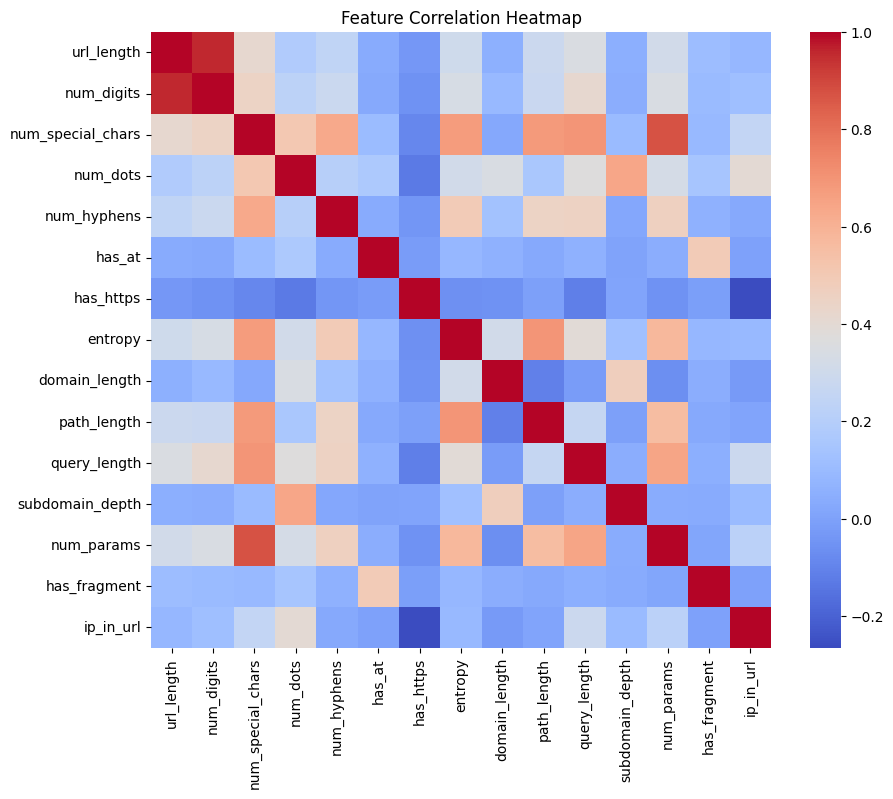

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
#sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
OUT_PATH = r"E:\file_main\Major_2\data\processed"

X.to_csv(f"{OUT_PATH}\\X_features.csv", index=False)
y.to_csv(f"{OUT_PATH}\\y_labels.csv", index=False)